In [1]:
import numpy as np
from skimage import io, util, measure, transform, draw
from scipy.ndimage import gaussian_filter
from scipy import interpolate
import pandas as pd
from imageUtils import normalize_image_intensity_signed

from os import path
import stackview
import matplotlib.pyplot as plt
import seaborn as sb
from glob import glob
from scipy.interpolate import NearestNDInterpolator

from measurements import get_mesh_from_bm_image, export_mesh, get_tissue_curvature_over_grid,get_tissue_curvature_sparse, \
    get_bm_image

from trimesh import Trimesh
import pyvista as pv
pv.set_jupyter_backend('trame')

%load_ext autoreload
%autoreload 2


In [242]:
calculate_height_image = False
calculate_mesh = False
calculate_curvature = False

dirnames = {'R1':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R1/Uncropped',
            'R2':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R2/Uncropped',
            'R5':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R4/Cropped',
            'R4':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R7/Cropped',
           'R3':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Time course/Prelim analysis',
           'R6':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R3/Cropped',
           'R7':'/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R6/Cropped'}

dz = {'R1':1,'R2':0.5,'R5':1,'R4':1,'R3':1,'R6':1,'R7':1}
dx = {'R1':0.3,'R2':0.3,'R5':0.4151329,'R4':0.4151329,'R6':0.4151329,'R3':.3,'R7':0.4151329}


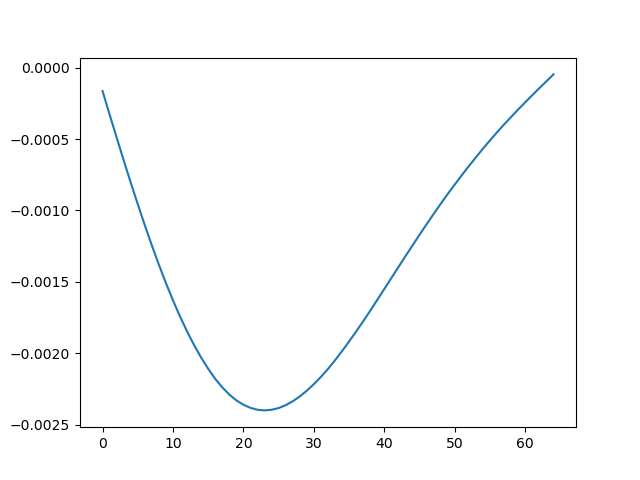

In [294]:
plt.close('all')
# plt.imshow(heightmap)
plt.plot(np.diff(grad)[:,500,500])
plt.show()

In [296]:
from measurements import make_image_from_heightmap,fix_holes_in_height_image
from imageUtils import get_z_gradient, find_z_of_maximal_gradient
from scipy.ndimage import gaussian_filter

region = 'R7'
dirname = dirnames[region]

calculate_height_image= True
calculate_mesh = False
calculate_curvature = False

# collagen = io.imread(path.join(dirname,'B.tif'))
k10 = io.imread(path.join(dirname,'G.tif'))
mem = io.imread(path.join(dirname,'R.tif'))
if calculate_height_image:
    # heightmap, height_image,grad = get_bm_image(k10,[5/dz[region],10/dx[region],10/dx[region]],
    #                                             +1, return_gradient=True, method='maximum',second_diff=True)
    
    im_z_blur = gaussian_filter(k10.astype(float),sigma=[5/dx[region],5/dx[region],5/dx[region]])
    grad = get_z_gradient(im_z_blur,+1)

    heightmap = np.diff(grad,axis=0).argmax(axis=0)
    # heightmap = np.zeros((k10.shape[1],k10.shape[2]),dtype=int)
    # for y in range(k10.shape[1]):
    #     for x in range(k10.shape[2]):
    #         _grad = grad[cutoff[y,x]:,y,x]
    #         heightmap[y,x] = cutoff[y,x] + _grad.argmax()
    
    height_image = make_image_from_heightmap(heightmap,k10.shape[0])
    heightmap,height_image = fix_holes_in_height_image(height_image,image_shape=k10.shape)
    
    io.imsave(path.join(dirname,'heightmap.tif'),heightmap)
    io.imsave(path.join(dirname,'height_image.tif'),height_image)
    io.imsave(path.join(dirname,'gradient.tif'),grad)
    
else:
    heightmap = io.imread(path.join(dirname,'heightmap.tif'))
    height_image = io.imread(path.join(dirname,'height_image.tif'))

if calculate_mesh:
    mesh = get_mesh_from_bm_image(height_image,spacing=[dz[region],dx[region],dx[region]],decimation_factor=60)
    export_mesh(mesh,path.join(dirname,'bm_mesh.npz'),
               values = get_tissue_curvature_sparse(mesh)[0])
else:
    mesh = np.load(path.join(dirname,'bm_mesh.npz'))
    mesh = Trimesh(mesh['vertices'],mesh['faces'])

if calculate_curvature:
    curvature,gaussian_curvature = get_tissue_curvature_over_grid(mesh,k10.shape,spacing=[dz[region],dx[region],dx[region]])
    curvature = curvature.T
    gaussian_curvature = gaussian_curvature.T
    np.savez(path.join(dirname,'mean_curvature.npz'),mean_curvature=curvature)
    np.savez(path.join(dirname,'gaussian_curvature.npz'),gaussian_curvature=gaussian_curvature)
else:
    curvature = np.load(path.join(dirname,'mean_curvature.npz'))['mean_curvature']
    gaussian_curvautre = np.load(path.join(dirname,'gaussian_curvature.npz'))['gaussian_curvature']

# mask = io.imread(path.join(dirname,'mask.tif')) > 1
# mask = draw.polygon2mask([k10.shape[1],k10.shape[2]],pd.read_csv(path.join(dirname,'mask.csv'))[['axis-1','axis-2']])

stackview.orthogonal(k10, zoom_factor=0.5,continuous_update=True)

/Users/xies/Desktop/Code/mouse_skin_size_control/utils/measurements.py:222: RuntimeWarning: invalid value encountered in cast
  interpolate.griddata(np.array([Y,X]).T,Z,(grid_y,grid_x), method='linear')).astype(int).T
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R6/Cropped/heightmap.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R6/Cropped/height_image.tif is a low contrast image
  return func(*args, **kwargs)


In [273]:
# Construct slicer
region = 'R7'
dirname = dirnames[region]

Nslice = 30
shift = 15

k10 = io.imread(path.join(dirname,'G.tif'))
mem = io.imread(path.join(dirname,'R.tif'))
height_image = io.imread(path.join(dirname,'height_image.tif'))
heightmap = height_image.argmax(axis=0)
io.imsave(path.join(dirname,'heightmap.tif'),heightmap)

k10_resliced = np.zeros((Nslice,*heightmap.shape),dtype=np.uint16)
mem_resliced = np.zeros((Nslice,*heightmap.shape),dtype=np.uint16)

for i in range(Nslice):
    _heightmap = np.clip(heightmap-15+i,a_min=0,a_max=k10.shape[0]-1)
    k10_resliced[i,:,:] = np.take_along_axis(k10, _heightmap[np.newaxis, :, :],axis=0)
    mem_resliced[i,:,:] = np.take_along_axis(mem, _heightmap[np.newaxis, :, :],axis=0)

io.imsave(path.join(dirname,'k10_resliced.tif'),k10_resliced)
io.imsave(path.join(dirname,'mem_resliced.tif'),mem_resliced)
stackview.switch( {'K10':k10_resliced,'mem':mem_resliced},
                 colormap=['pure_green','pure_yellow'], zoom_factor=0.5, toggleable=True)

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R6/Cropped/heightmap.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R6/Cropped/k10_resliced.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R6/Cropped/mem_resliced.tif is a low contrast image
  return func(*args, **kwargs)


In [280]:
# Normalize by mean basal layer K10 intensity

basal_ranges = {'R1':np.arange(8,11),
                'R2':np.arange(2,4),
               'R3':np.arange(8,9),
               'R4':np.arange(8,9),
               'R6':np.arange(14,17),
               'R7':np.arange(12,16)}

for region in ['R1','R2','R3','R4','R6','R7']:
    dirname = dirnames[region]
    print(dirname)
    k10_resliced = io.imread(path.join(dirname,'k10_resliced.tif'))
    mem_resliced = io.imread(path.join(dirname,'mem_resliced.tif'))

    Zbasal = basal_ranges[region]
    Ibasal = k10_resliced[Zbasal,:]

    k10_resliced_norm = k10_resliced[Zbasal,:].max(axis=0).astype(float)/Ibasal.mean()
    io.imsave(path.join(dirname,'k10_resliced_single.tif'),util.img_as_uint(k10_resliced[np.median(Zbasal).astype(int)]))
    io.imsave(path.join(dirname,'k10_resliced_norm.tif'),util.img_as_uint(k10_resliced_norm/k10_resliced_norm.max()))
    io.imsave(path.join(dirname,'mem_resliced_basal.tif'),util.img_as_uint(mem_resliced[np.median(Zbasal).astype(int)]))

/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R1/Uncropped
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R2/Uncropped


/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R1/Uncropped/k10_resliced_single.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R1/Uncropped/mem_resliced_basal.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R2/Uncropped/mem_resliced_basal.tif is a low contrast image
  return func(*args, **kwargs)


/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Time course/Prelim analysis
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R7/Cropped
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R3/Cropped
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R6/Cropped


/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Time course/Prelim analysis/mem_resliced_basal.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R7/Cropped/k10_resliced_single.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R7/Cropped/mem_resliced_basal.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/T

In [281]:
# Visualize
region = 'R7'

mean_curvature = np.load(path.join(dirnames[region],'mean_curvature.npz'))['mean_curvature']
if mean_curvature.ndim == 3:
    mean_curvature = mean_curvature[0,...]
    
mem_resliced = io.imread(path.join(dirnames[region],'mem_resliced_basal.tif'))
k10_resliced = io.imread(path.join(dirnames[region],'k10_resliced_single.tif'))
stackview.switch( {'K10':mean_curvature,'mem':mem_resliced}, colormap=['pure_green','pure_yellow'], zoom_factor=0.5, toggleable=True)


In [282]:
for region,dirname in dirnames.items():
    filelist = glob(path.join(dirname,'mem_resliced_basal_seg.npy'))
    m = np.load(filelist[0],allow_pickle=True).item()['masks']
    io.imsave(path.join(dirname,'cp_masks_raw.tif'),m)

masks = {}
for region,dirname in dirnames.items():
    masks[region] = io.imread(path.join(dirname,'cp_masks.tif'))
print(masks.keys())

dict_keys(['R1', 'R2', 'R5', 'R4', 'R3', 'R6', 'R7'])


/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R1/Uncropped/cp_masks_raw.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R2/Uncropped/cp_masks_raw.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R4/Cropped/cp_masks_raw.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10

In [283]:
all_df = []
for region,dirname in dirnames.items():

    print(region)
    mean_curvature = np.load(path.join(dirnames[region],'mean_curvature.npz'))['mean_curvature']
    if mean_curvature.ndim == 3:
        mean_curvature = mean_curvature[0,...]
    k10_resliced = io.imread(path.join(dirnames[region],'k10_resliced_norm.tif'))
    if region == 'R3' or region == 'R5':
        mean_curvature = mean_curvature.T
    # k10_resliced = util.img_as_ubyte(k10_resliced)
    df = pd.DataFrame(measure.regionprops_table(masks[region],intensity_image=k10_resliced,
                                                properties=['label','area','centroid','mean_intensity'])).set_index('label')
    df['Region'] = region
    df = df.rename(columns={'mean_intensity':'k10'})
    df2 = pd.DataFrame(measure.regionprops_table(masks[region],intensity_image=mean_curvature,
                                                 properties=['label','mean_intensity'])).set_index('label')
    df2 = df2.rename(columns={'mean_intensity':'curvature'})
    df = pd.merge(df,df2,left_index=True,right_index=True)
    
    df['K10 normalized'] = df['k10'] / df['k10'].mean()
    
    all_df.append(df.reset_index())
    # masks[region]
all_df = pd.concat(all_df,ignore_index=True)
all_df = all_df[all_df['area'] > 100].reset_index(drop=True)
all_df['Log-K10'] = np.log(all_df['K10 normalized'])
all_df

R1
R2
R5
R4
R3
R6
R7


,label,area,centroid-0,centroid-1,k10,Region,curvature,K10 normalized,Log-K10
0,43,715.0,27.387413,394.076923,2464.613986,R1,-0.005776,0.861482,-0.149101
1,44,386.0,23.279793,457.028497,2960.204663,R1,0.191213,1.034711,0.034123
2,45,590.0,28.183051,678.435593,2283.728814,R1,0.074156,0.798256,-0.225326
3,48,593.0,28.295110,500.215852,2477.016863,R1,-0.109033,0.865818,-0.144081
4,51,492.0,26.052846,478.668699,2423.313008,R1,0.089876,0.847046,-0.166000
...,...,...,...,...,...,...,...,...,...
10095,2467,105.0,815.438095,274.438095,6283.038095,R7,0.224928,3.074289,1.123074
10096,2469,266.0,816.834586,454.018797,941.045113,R7,0.080650,0.460453,-0.775544
10097,2475,222.0,819.454955,822.756757,1388.031532,R7,-0.101862,0.679164,-0.386893
10098,2479,276.0,820.528986,623.340580,3352.173913,R7,0.110752,1.640218,0.494829


In [284]:
region = 'R7'
df = all_df[all_df['Region'] == region].set_index('label')
k10_resliced = io.imread(path.join(dirnames[region],'k10_resliced_norm.tif'))

stackview.clusterplot(image=k10_resliced,
                     labels=masks[region],
                     df= df,
                     column_x="area",
                     column_y="Log-K10", 
                     zoom_factor=0.4,
                     alpha=0.2)


In [71]:
df.loc[591]

area                     435.0
centroid-0          344.216092
centroid-1          282.526437
k10               31897.034483
Region                      R2
curvature             0.119282
K10 normalized        8.545329
Log-K10               2.145385
Name: 591, dtype: object

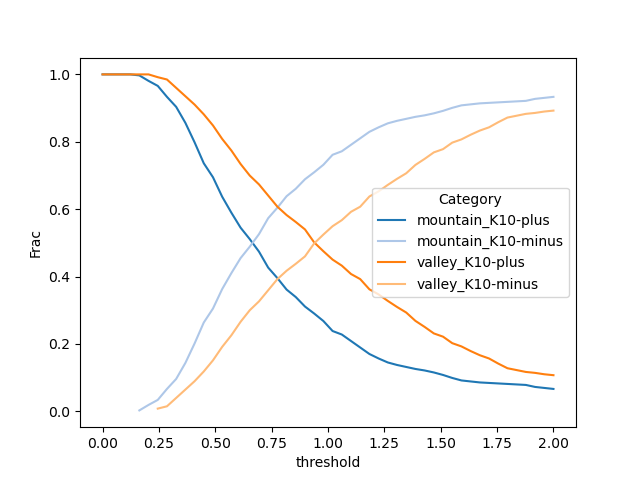

In [285]:
region = 'R7'
df = all_df.set_index('Region').loc[region]
concavity_dict = {True:'valley',False:'mountain'}
k10_dict = {True:'K10-minus',False:'K10-plus'}

counts = []
for th in np.linspace(0,2,50):
    df['K10-minus'] = df['K10 normalized'] < th
    df['Concavity'] = df['curvature'] > 0
    # _df = df.groupby(['Concavity','K10-minus'])['area'].count()
    _df = pd.DataFrame(df.groupby(['Concavity','K10-minus'])['area'].count()).T.melt()
    _df.loc[_df['Concavity'],'value'] /= _df.loc[_df['Concavity'],'value'].sum()
    _df.loc[~_df['Concavity'],'value'] /= _df.loc[~_df['Concavity'],'value'].sum()
    
    _df['Category'] = _df['Concavity'].map(concavity_dict) + '_' + _df['K10-minus'].map(k10_dict)
    _df = _df.drop(columns=['Concavity','K10-minus'])
    _df = _df.rename(columns={'value':'Frac'})
    # _df['Frac'] /= len(df)
    _df['threshold'] = th
    counts.append(_df)

counts = pd.concat(counts,ignore_index=True)
counts
plt.figure()
sb.lineplot(counts,x='threshold',y='Frac',hue='Category',
           hue_order=['mountain_K10-plus','mountain_K10-minus','valley_K10-plus','valley_K10-minus'],
           palette='tab20')
plt.show()

R1
PearsonRResult(statistic=np.float64(-0.14701336517747637), pvalue=np.float64(2.5881149464633047e-08))
R2
PearsonRResult(statistic=np.float64(-0.01104160818402314), pvalue=np.float64(0.699325302587999))
R3
PearsonRResult(statistic=np.float64(-0.01965400362276304), pvalue=np.float64(0.5561770060317088))
R4
PearsonRResult(statistic=np.float64(0.07401134225850611), pvalue=np.float64(0.002954966310203466))
R5
PearsonRResult(statistic=np.float64(0.021784309911412492), pvalue=np.float64(0.35087080846134827))
R6
PearsonRResult(statistic=np.float64(0.35328617159734127), pvalue=np.float64(2.552549076937363e-51))
R7
PearsonRResult(statistic=np.float64(0.29205950018663335), pvalue=np.float64(5.95758084596571e-29))


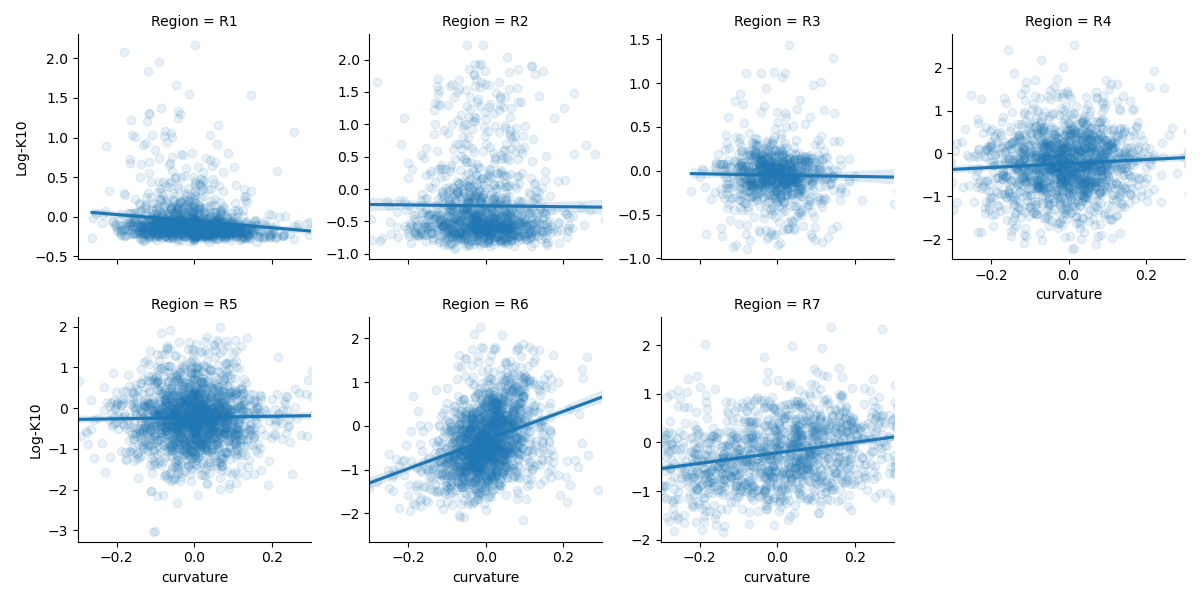

In [286]:
from basicUtils import nonan_pairs
from scipy import stats

g = sb.FacetGrid(all_df,col='Region',col_wrap=4,sharey=False,col_order=['R1','R2','R3','R4','R5','R6','R7'])
g.map(sb.regplot,'curvature','Log-K10',scatter_kws={'alpha':0.1})
plt.xlim([-.3,.3])

for name,region in all_df.groupby('Region'):
    print(name)
    X,Y = nonan_pairs(region['curvature'],region['Log-K10'])
    print(stats.pearsonr(X,Y))
    

(np.float64(-7.242956501387644), np.float64(4.687724444752889e-13))

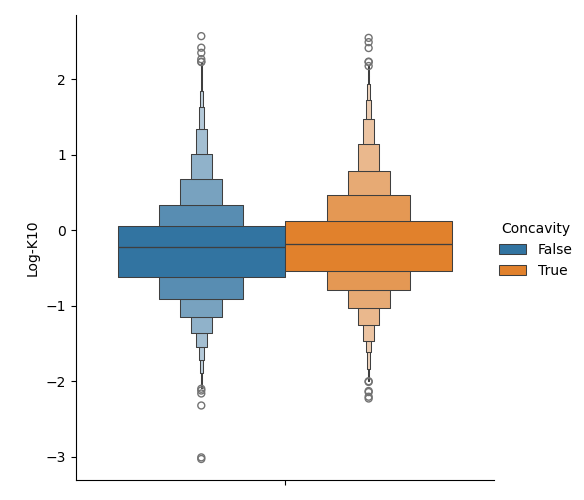

In [226]:
from basicUtils import ttest_from_groupby
all_df['Concavity'] = all_df['curvature'] > 0
sb.catplot(all_df,hue='Concavity',y='Log-K10',sharey=False,kind='boxen')
plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Figures/k1o_concavity_catplot.svg')

ttest_from_groupby(all_df,field2group='Concavity',field2test='Log-K10')

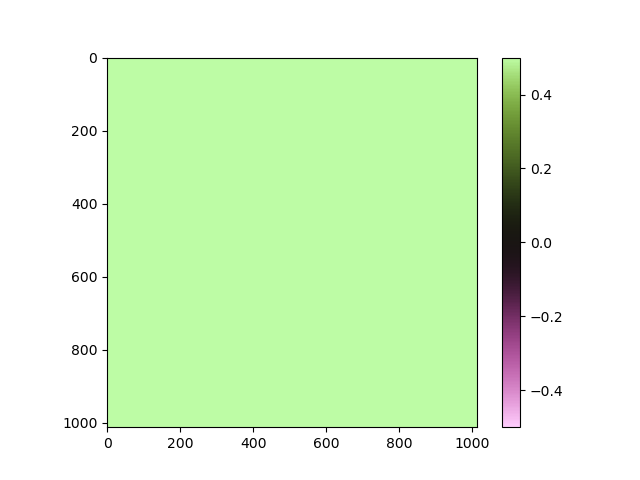

In [56]:
plt.figure()
plt.imshow(k10_resliced,vmin=-.5,vmax=.5,cmap='vanimo')
plt.colorbar()
plt.show()
plt.savefig('/Users/xies/Desktop/vanimo.svg')

Region R1, T-test P = 7.87e-08
Region R2, T-test P = 8.85e-02
Region R3, T-test P = 6.89e-09
Region R4, T-test P = 1.02e-01
Region R5, T-test P = 6.11e-01
Region R6, T-test P = 5.51e-30
Region R7, T-test P = 8.31e-18


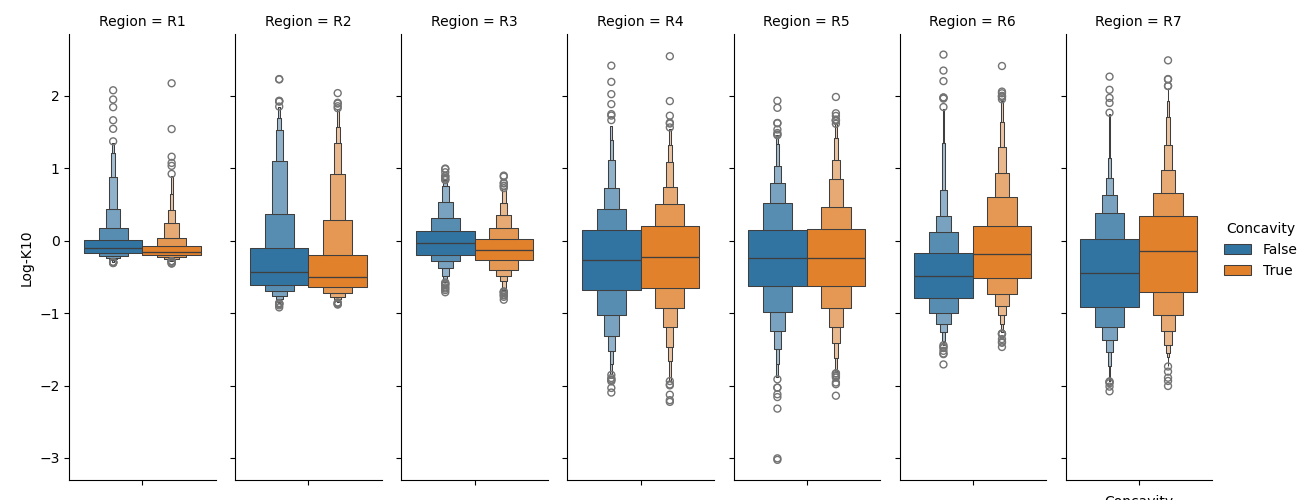

In [255]:
all_df['Concavity'] = all_df['curvature'] > 0
sb.catplot(all_df,hue='Concavity',y='Log-K10',col='Region',sharey=True,kind='boxen',
          aspect=0.35,col_order=['R1','R2','R3','R4','R5','R6','R7'])
plt.xlabel('Concavity')
plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Figures/k1o_concavity_catplot_by_region.svg')

for name,df in all_df.groupby('Region'):
    R,P = ttest_from_groupby(df,field2group='Concavity',field2test='Log-K10')
    print(f'Region {name}, T-test P = {P:.2e}')

## Gate K10- v. K10+ cells

In [76]:
sb.histplot(all_df,x='k10',hue='Region',element='poly')


<Axes: xlabel='curvature', ylabel='Log-K10'>

# More manual approach?

In [514]:
import pandas as pd
from skimage import measure, filters
import seaborn as sb
from basicUtils import plot_bin_means

masks = np.load(path.join(dirname,'mem_resliced_z7_seg.npy'),allow_pickle=True).item()['masks']
# masks = io.imread(path.join(dirname,'mem_resliced_z3_masks.tif')) * mask

# k10_max = (k10[5,...]).max(axis=0).astype(float)*mask
k10_max = k10_resliced[18,...]

df = pd.DataFrame(measure.regionprops_table(masks,intensity_image=k10_max,properties=['label','intensity_mean']))
df = df.set_index('label').rename(columns={'intensity_mean':'k10'})
df_ = pd.DataFrame(measure.regionprops_table(masks,intensity_image=curvature,properties=['label','intensity_mean']))
df_ = df_.set_index('label').rename(columns={'intensity_mean':'curvature'})
# df_ = pd.DataFrame(measure.regionprops_table(masks,intensity_image=gaussian_curvautre,properties=['label','intensity_mean']))
# df_ = df_.set_index('label').rename(columns={'intensity_mean':'gaussian_curvature'})

df = pd.merge(df,df_,left_index=True,right_index=True)
df['log-k10'] = np.log(df['k10'])
sb.scatterplot(df,y='k10',x='curvature',alpha=0.1)
plot_bin_means(df['curvature'],df['k10'],bin_edges=20,minimum_n=20,color='r',mean='median')

df.to_csv(path.join(dirname,'data_frame.csv'))


FileNotFoundError: [Errno 2] No such file or directory: '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R7/Cropped/mem_resliced_z7_seg.npy'

In [162]:
stackview.switch({'k10':k10_max*mask,
                    'mean':curvature},
                colormap=['pure_green','pure_magenta'],
                toggleable=True)

NameError: name 'k10_max' is not defined

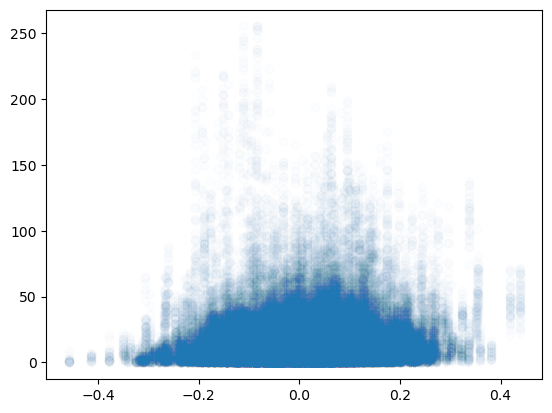

In [385]:
plt.scatter((curvature*mask).flatten(),(k10_resliced[18,...]*mask).flatten(),alpha=0.01)

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


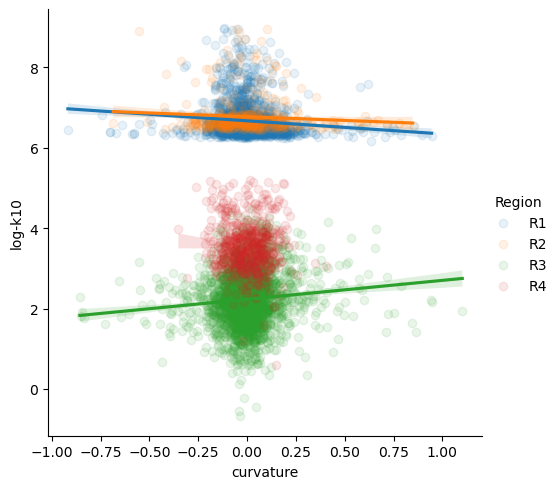

In [387]:
df1 = pd.read_csv('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R1/Uncropped/data_frame.csv',index_col='label')
df1['Region'] = 'R1'
df2 = pd.read_csv('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R2/Cropped/data_frame.csv',index_col='label')
df2['Region'] = 'R2'
df3 = pd.read_csv('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R4/Cropped/data_frame.csv',index_col='label')
df3['Region'] = 'R3'
df4= pd.read_csv('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R7/Cropped/data_frame.csv',index_col='label')
df4['Region'] = 'R4'
df = pd.concat((df1,df2,df3,df4),ignore_index=True)
sb.lmplot(df,x='curvature',y='log-k10',hue='Region',scatter_kws={'alpha':0.1})
# plot_bin_means(df['curvature'],df['log-k10'],bin_edges=40,minimum_n=50,mean='mean',color='r')
# plt.xlim([-.5,.5])
# plt.ylim([6,8])

plt.gcf().savefig(path.join('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Figures/k10_v_curvature.svg'))

In [85]:
from scipy import stats

stats.pearsonr(df['curvature'],df['log-k10'])

PearsonRResult(statistic=np.float64(-0.09783836887916617), pvalue=np.float64(2.9066975143682647e-06))

In [255]:
# Load resliced 3D manually gated cells

In [334]:
k10_plus = pd.read_csv(path.join(dirname,'K10+.csv'),index_col=0)
k10_minus = pd.read_csv(path.join(dirname,'K10-.csv'),index_col=0)

resliced_masks = io.imread(path.join(dirname,'mem_resliced_cp_masks.tif'))
resliced_k10 = io.imread(path.join(dirname,'k10_resliced.tif'))
resliced_k10_sub = resliced_k10.copy() - filters.threshold_otsu(resliced_k10)
resliced_k10_sub[resliced_k10_sub < 0] = 0
mean_curvature = np.load(path.join(dirname,'mean_curvature.npz'))['mean_curvature'][0,...]
df = pd.DataFrame(measure.regionprops_table(resliced_masks,intensity_image=resliced_k10_sub,properties=['area','centroid','label','mean_intensity']))

In [335]:
# Filter for cells of interest

for idx,centroid in k10_plus.iterrows():
    Z,Y,X = centroid[['axis-0','axis-1','axis-2']].astype(int)
    l = resliced_masks[Z,Y,X]
    if l > 0:
        df.loc[df['label'] == l, 'K10'] = 'Plus'
        df.loc[df['label'] == l, 'Mean curvature'] = mean_curvature[Y,X]

for idx,centroid in k10_minus.iterrows():
    Z,Y,X = centroid[['axis-0','axis-1','axis-2']].astype(int)
    l = resliced_masks[Z,Y,X]
    if l > 0:
        df.loc[df['label'] == l, 'K10'] = 'Minus'
        df.loc[df['label'] == l, 'Mean curvature'] = mean_curvature[Y,X]


In [336]:
df.groupby('K10').count()

,area,centroid-0,centroid-1,centroid-2,label,mean_intensity,Mean curvature
K10,,,,,,,
Minus,121,121,121,121,121,121,121
Plus,66,66,66,66,66,66,66


In [163]:
stackview.switch({'k10':resliced_k10,'curv':mean_curvature},zoom_factor=0.5,colormap=['pure_green','pure_magenta'])

NameError: name 'resliced_k10' is not defined

In [338]:
stackview.slice(mean_curvature,zoom_factor=0.5)

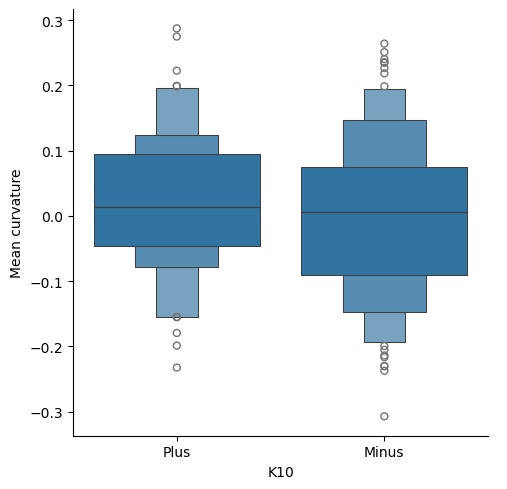

In [339]:
sb.catplot(df.dropna(subset='K10'),x='K10',y='Mean curvature',kind='boxen')